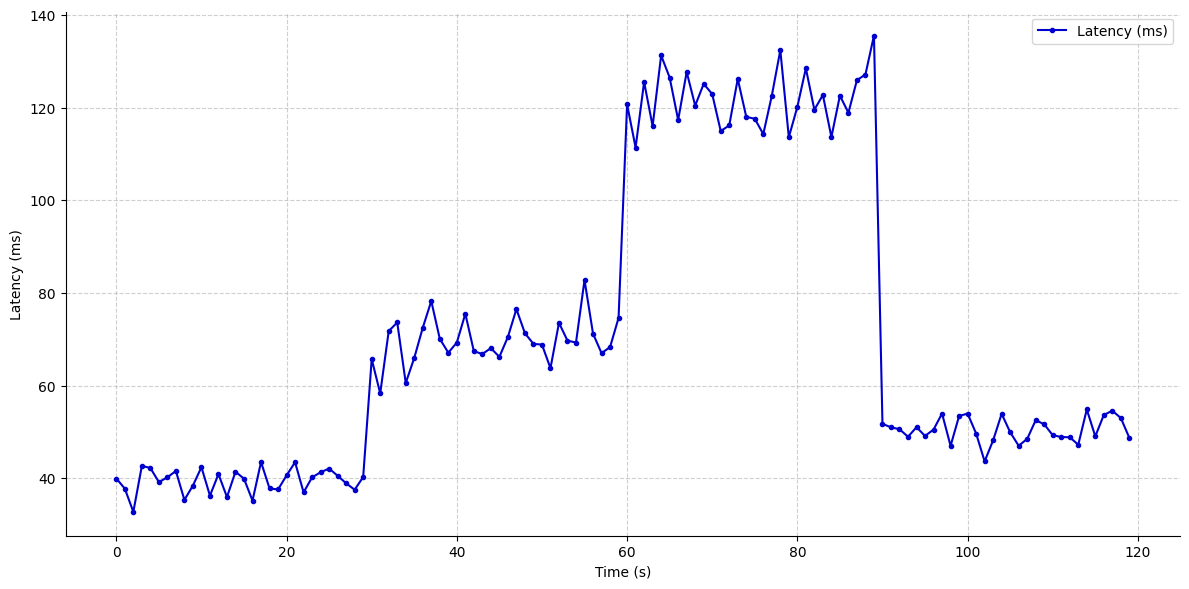

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Generate time axis
time = np.arange(0, 120, 1)  # 2 minutes, 1-second intervals

# Simulate level shifts
latency = np.empty_like(time, dtype=float)
latency[:30] = np.random.normal(loc=40, scale=3, size=30)   # Normal baseline
latency[30:60] = np.random.normal(loc=70, scale=4, size=30)  # Slight degradation
latency[60:90] = np.random.normal(loc=120, scale=6, size=30) # Major issue
latency[90:] = np.random.normal(loc=50, scale=3, size=30)    # Recovered baseline

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time, latency, marker='.', linestyle='-', color='mediumblue', label='Latency (ms)')
# plt.axhline(y=100, color='red', linestyle='--', label='Warning Threshold (100ms)')

# Optional annotations
# plt.text(35, 75, 'Minor Degradation', color='gray')
# plt.text(65, 125, 'Major Latency Spike', color='gray')
# plt.text(95, 55, 'Recovery', color='gray')

# plt.title('Simulated Latency Timeline with Level Shifts')
plt.xlabel('Time (s)')
plt.ylabel('Latency (ms)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


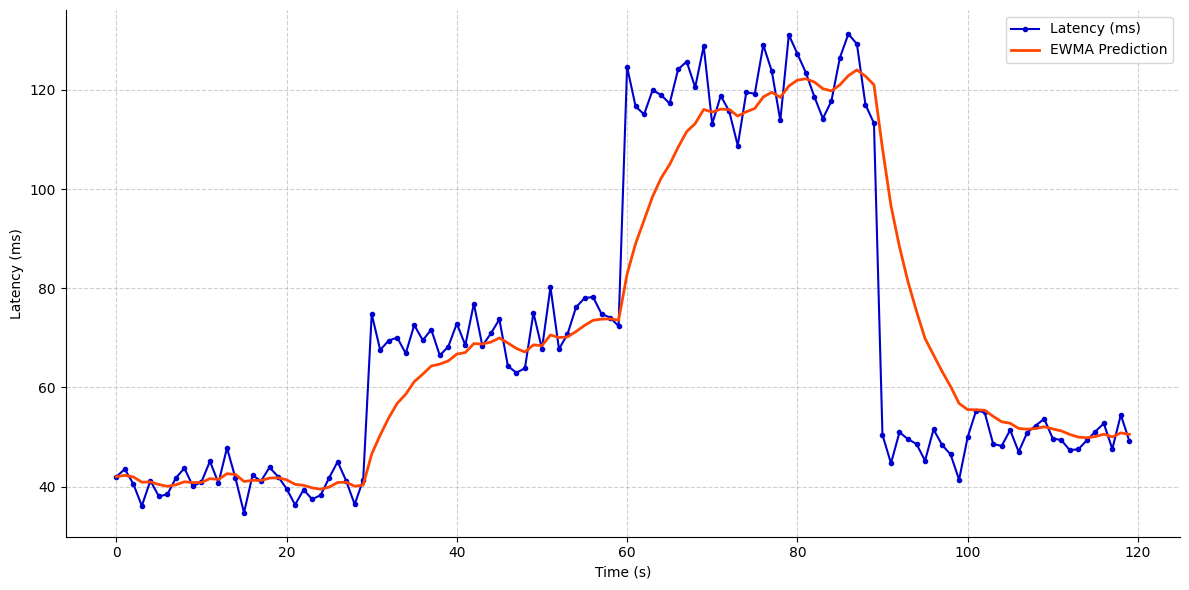

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Generate time axis
time = np.arange(0, 120, 1)  # 2 minutes, 1-second intervals

# Simulate level shifts
latency = np.empty_like(time, dtype=float)
latency[:30] = np.random.normal(loc=40, scale=3, size=30)   # Normal baseline
latency[30:60] = np.random.normal(loc=70, scale=4, size=30)  # Slight degradation
latency[60:90] = np.random.normal(loc=120, scale=6, size=30) # Major issue
latency[90:] = np.random.normal(loc=50, scale=3, size=30)    # Recovered baseline

# Compute EWMA (exponential smoothing)
latency_series = pd.Series(latency)
ewma = latency_series.ewm(span=10, adjust=False).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time, latency, marker='.', linestyle='-', color='mediumblue', label='Latency (ms)')
plt.plot(time, ewma, color='orangered', linewidth=2, label='EWMA Prediction')

# plt.title('Simulated Latency Timeline with EWMA Trend')
plt.xlabel('Time (s)')
plt.ylabel('Latency (ms)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


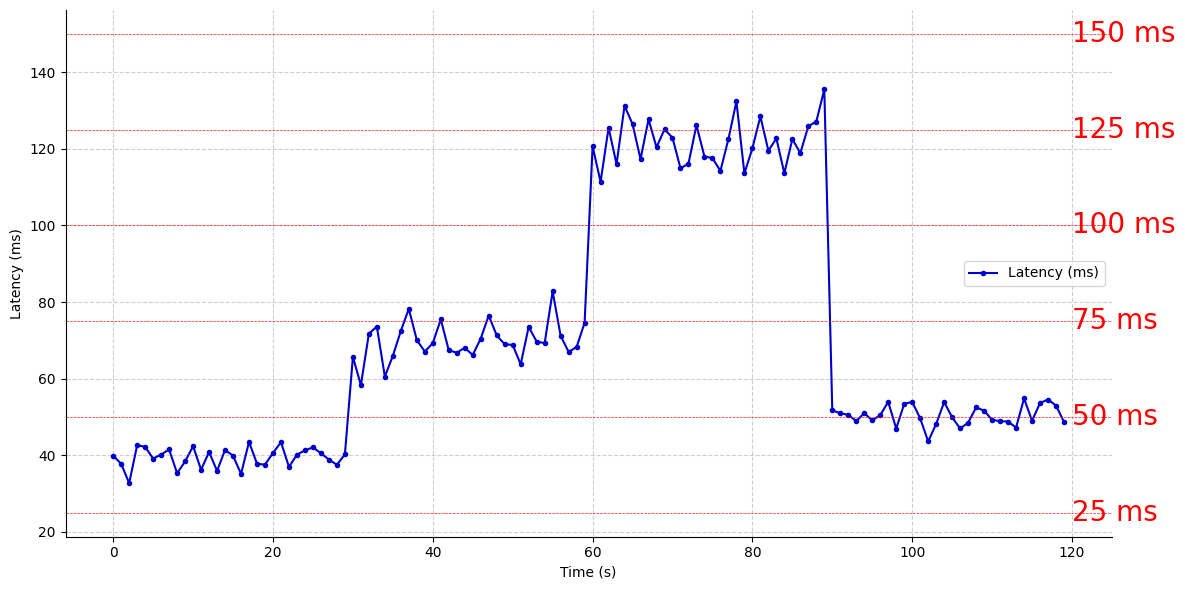

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(
    time, latency, marker=".", linestyle="-", color="mediumblue", label="Latency (ms)"
)
# plt.plot(time, ewma, color='orangered', linewidth=2, label='EWMA Prediction')

# Add horizontal threshold lines at every 25ms
for thresh in range(25, int(np.max(latency)) + 25, 25):
    plt.axhline(y=thresh, color="red", linestyle="--", linewidth=0.5, alpha=0.9)
    plt.text(
        time[-1] + 1, thresh, f"{thresh} ms", va="center", fontsize=20, color="red"
    )

# plt.title('Simulated Latency Timeline with EWMA and Thresholds')
plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Remove top and right spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


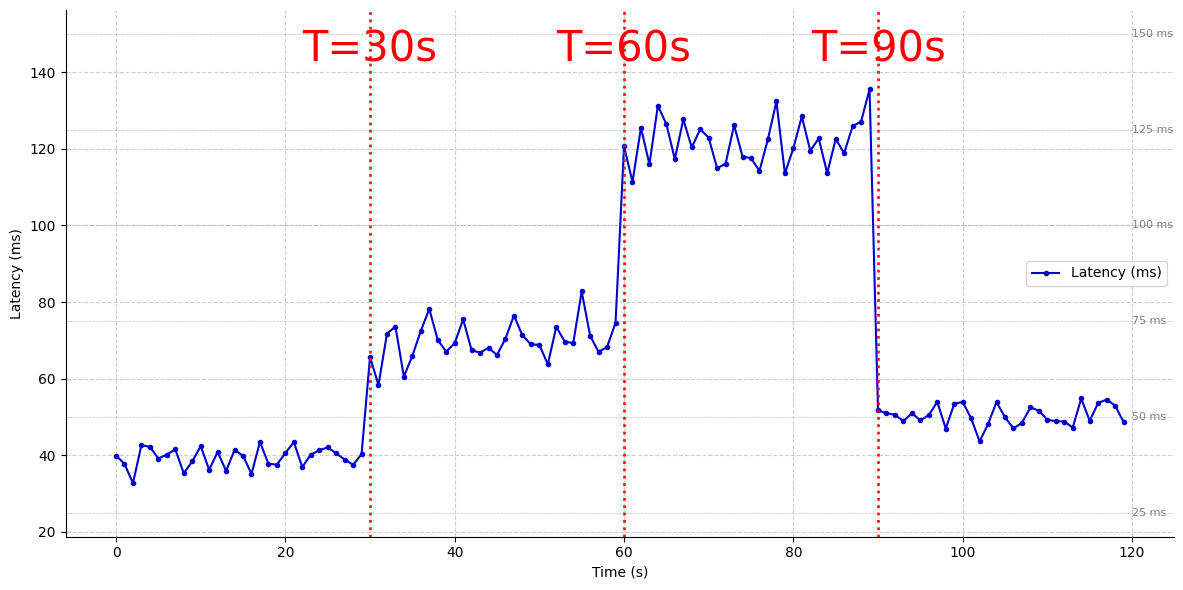

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(time, latency, marker='.', linestyle='-', color='mediumblue', label='Latency (ms)')
# plt.plot(time, ewma, color='orangered', linewidth=2, label='EWMA Prediction')

# Horizontal threshold lines (25ms steps)
for thresh in range(25, int(np.max(latency)) + 25, 25):
    plt.axhline(y=thresh, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.text(time[-1] + 1, thresh, f'{thresh} ms', va='center', fontsize=8, color='gray')

# Vertical lines for level shifts
for shift in [30, 60, 90]:
    plt.axvline(x=shift, color='red', linestyle=':', linewidth=2, alpha=0.9)
    plt.text(shift, np.max(latency) + 5, f'T={shift}s', ha='center', va='bottom', fontsize=30, color='red')

# plt.title('Simulated Latency Timeline with EWMA, Thresholds, and Level Shifts')
plt.xlabel('Time (s)')
plt.ylabel('Latency (ms)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
